In [175]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [176]:
rng = np.random.default_rng(seed=42)

data = rng.normal(100, 20, 200)
data = np.append(data, [300, 5])

In [177]:
mean = np.mean(data)
std = np.std(data)

print(mean, std)

99.91681733361582 23.442695707715913


In [178]:
outliers = data[np.abs(data - mean) > 2*std]

outliers

array([158.27724932, 300.        ,   5.        ])

<Axes: ylabel='Density'>

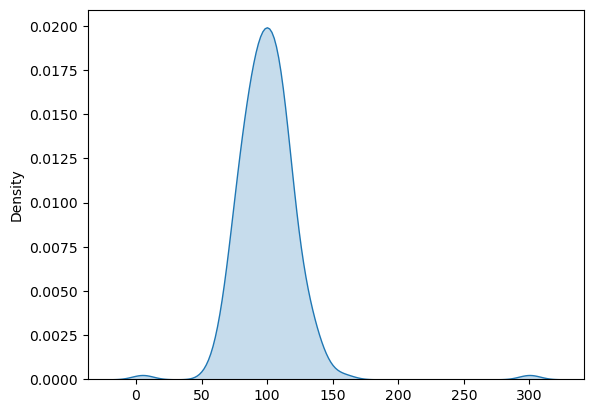

In [179]:
sns.kdeplot(data, fill=True)

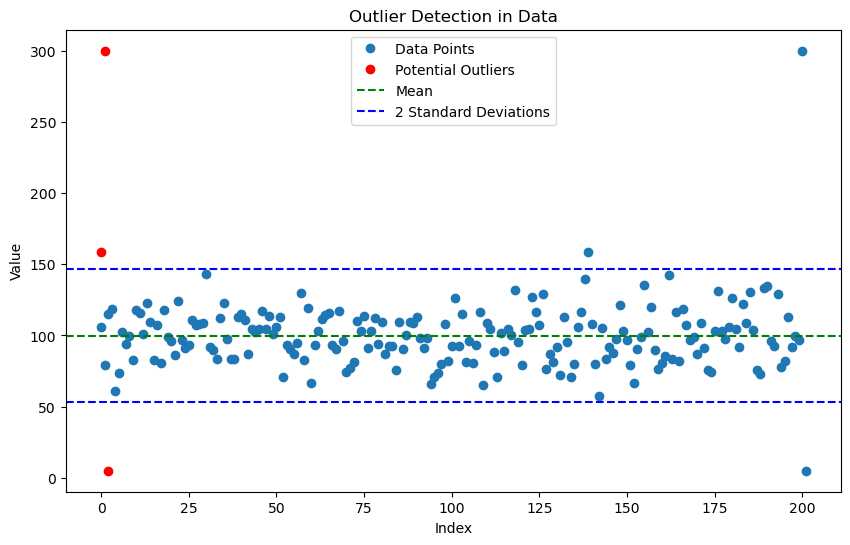

In [180]:
plt.figure(figsize=(10, 6))
plt.plot(data, 'o', label='Data Points')
plt.plot(outliers, 'ro', label='Potential Outliers')
plt.axhline(mean, color='g', linestyle='dashed', label='Mean')
plt.axhline(mean + 2*std, color='b', linestyle='dashed', label='2 Standard Deviations')
plt.axhline(mean - 2*std, color='b', linestyle='dashed')
plt.title('Outlier Detection in Data')
plt.xlabel('Index')
plt.ylabel('Value')
plt.legend()
plt.show()

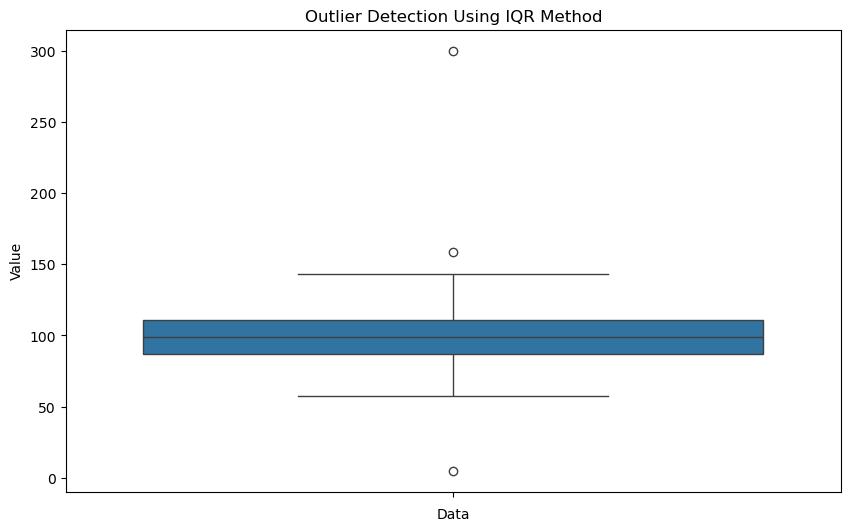

In [181]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=data)
plt.title('Outlier Detection Using IQR Method')
plt.xlabel('Data')
plt.ylabel('Value')
plt.show()

<Axes: >

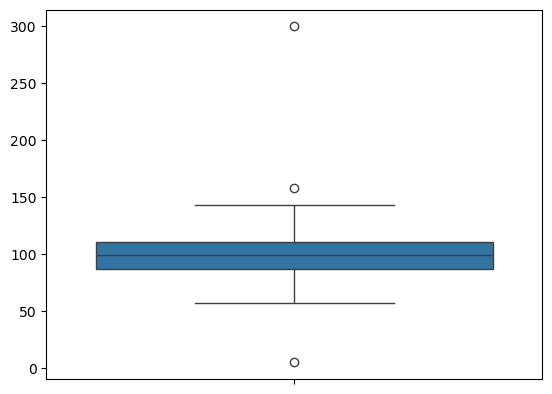

In [182]:
sns.boxplot(data)

In [183]:
# Actual Removal / Above was also right

<Axes: ylabel='Count'>

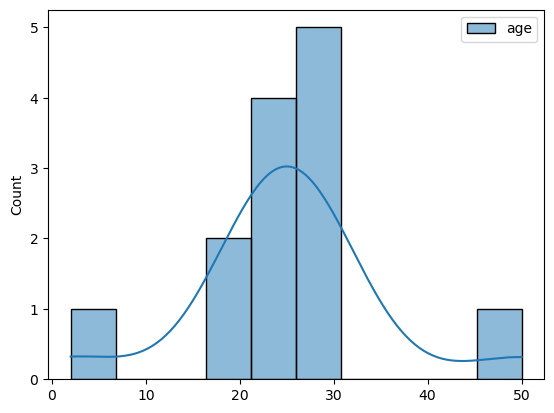

In [184]:
data = pd.DataFrame({'age': [2, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 50]})
sns.histplot(data, kde=True)

<Axes: >

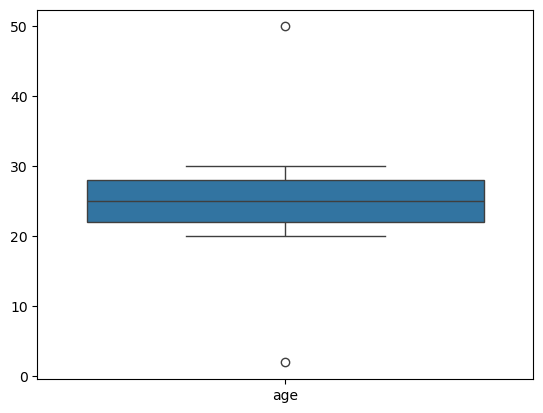

In [185]:
sns.boxplot(data)

In [186]:
mean = data['age'].mean()
std = data['age'].std()

print(mean, std)

25.153846153846153 10.261953630166738


In [187]:
data["z_score"] = (data['age'] - mean)/std

print(data[data['z_score'].between(-2,2)])

    age   z_score
1    20 -0.502229
2    21 -0.404781
3    22 -0.307334
4    23 -0.209887
5    24 -0.112439
6    25 -0.014992
7    26  0.082455
8    27  0.179903
9    28  0.277350
10   29  0.374797
11   30  0.472245


In [188]:
# mask_data = (data['z_score']<2) & (data['z_score']>-2)
# mask_outliers = (data['z_score']>2) & (data['z_score']<-2)

In [189]:
outliers = data[np.abs(data['z_score'])>=2]
data = data[data['z_score'].between(-2,2)]

print(data)
print(outliers)

    age   z_score
1    20 -0.502229
2    21 -0.404781
3    22 -0.307334
4    23 -0.209887
5    24 -0.112439
6    25 -0.014992
7    26  0.082455
8    27  0.179903
9    28  0.277350
10   29  0.374797
11   30  0.472245
    age   z_score
0     2 -2.256281
12   50  2.421191


In [193]:
# Import libraries
import numpy as np
from scipy import stats

# Sample data
data = np.array([2.5, 2.7, 2.8, 3.0, 3.2, 3.4, 3.6, 3.8, 4.0, 110.0, 115.6])
print(f'Data: {data}')

z_scores = np.abs(stats.zscore(data))

threshold = 2
outliers = np.where(z_scores > threshold)[0]

mask = z_scores < threshold
data = data[mask]

print(f'Outliers: {outliers}')
print(f'Filtered Data: {data}')

Data: [  2.5   2.7   2.8   3.    3.2   3.4   3.6   3.8   4.  110.  115.6]
Outliers: [ 9 10]
Filtered Data: [2.5 2.7 2.8 3.  3.2 3.4 3.6 3.8 4. ]
